In [1]:
import pandas as pd

df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [3]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [4]:
df[['OnlineBackup']].head()

,OnlineBackup
0,Yes
1,No
2,Yes
3,No
4,No


In [5]:
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)


Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data types:
 customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod    

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)
df.drop('customerID', axis=1, inplace=True)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0, 'Male': 1, 'Female': 0})

In [7]:
multi_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
              'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

In [8]:
print("\nMissing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)


Missing values:
 gender                                   0
SeniorCitizen                            0
Partner                                  0
Dependents                               0
tenure                                   0
PhoneService                             0
PaperlessBilling                         0
MonthlyCharges                           0
TotalCharges                             0
Churn                                    0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service     

In [9]:
df.describe(include='all')

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,False,False,False,False,False,False,False,False,False
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4999,5517,4336,5517,4311,5570,5348,5521,4678,5431
mean,0.504756,0.162147,0.483033,0.299588,32.371149,0.903166,0.592219,64.761692,2279.734304,0.265370,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.500013,0.368612,0.499748,0.458110,24.559481,0.295752,0.491457,30.090047,2266.794470,0.441561,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.500000,398.550000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1394.550000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.850000,3786.600000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [11]:
print("\nData types:\n", df.dtypes)


Data types:
 gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
TotalCharges                             float64
Churn                                      int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSu

In [12]:
print(df.dtypes.value_counts())

int64      29
float64     2
Name: count, dtype: int64


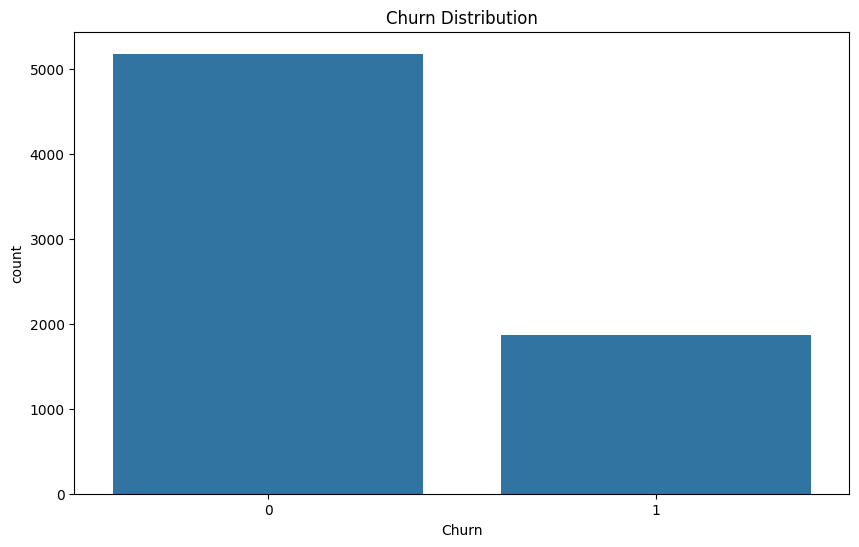

Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

print(df['Churn'].value_counts(normalize=True))

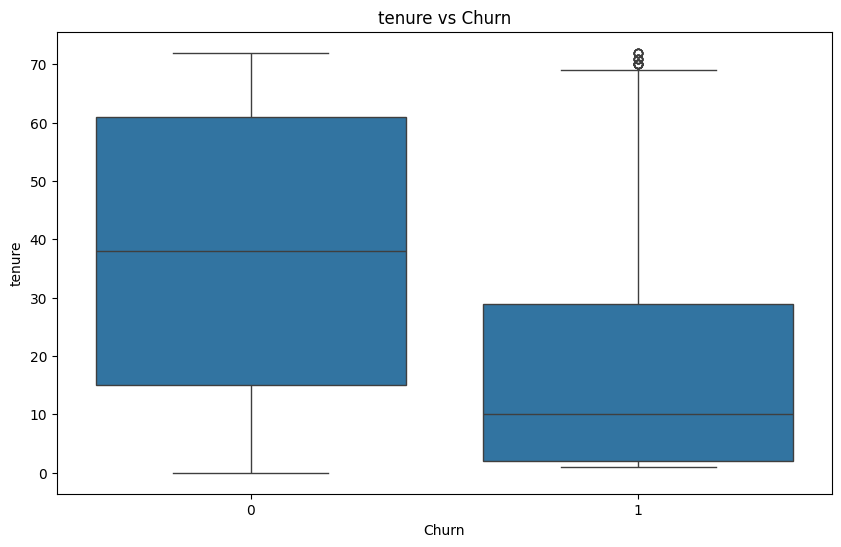

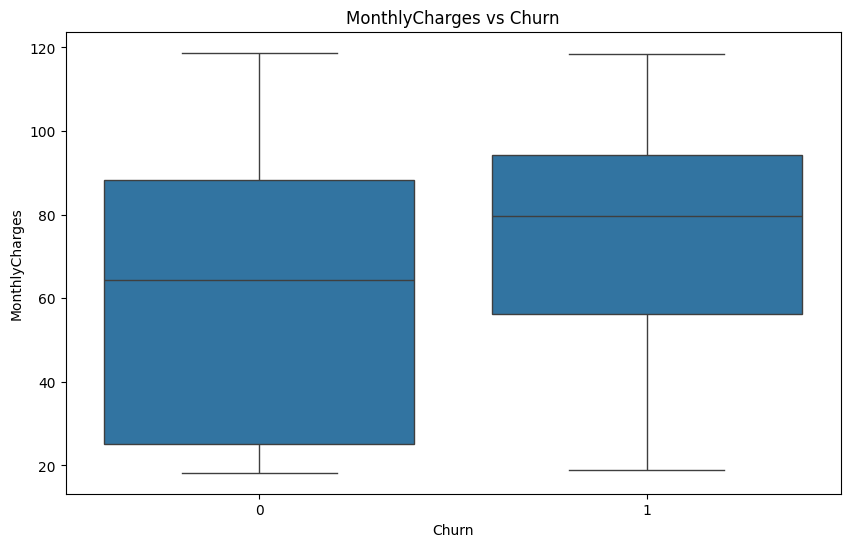

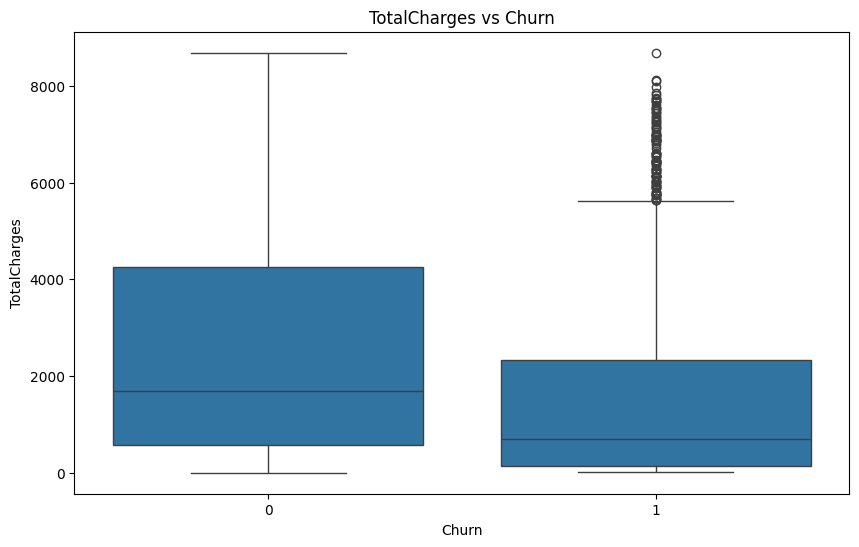

In [14]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

for col in num_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.show()

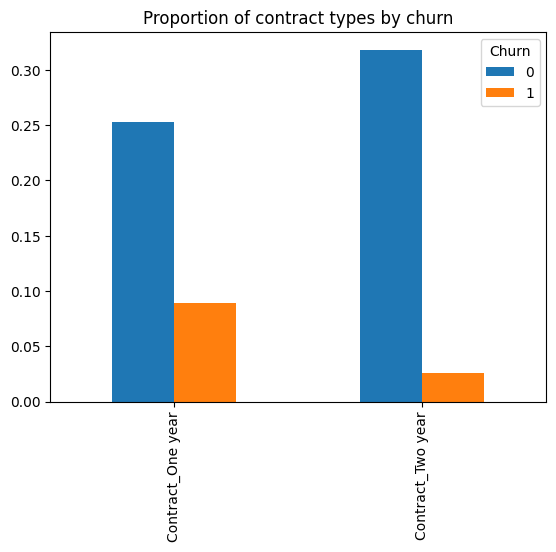

In [15]:
contract_cols = ['Contract_One year', 'Contract_Two year'] 
contract_churn = df[contract_cols + ['Churn']].groupby('Churn').mean()
contract_churn.T.plot(kind='bar')
plt.title('Proportion of contract types by churn')
plt.show()

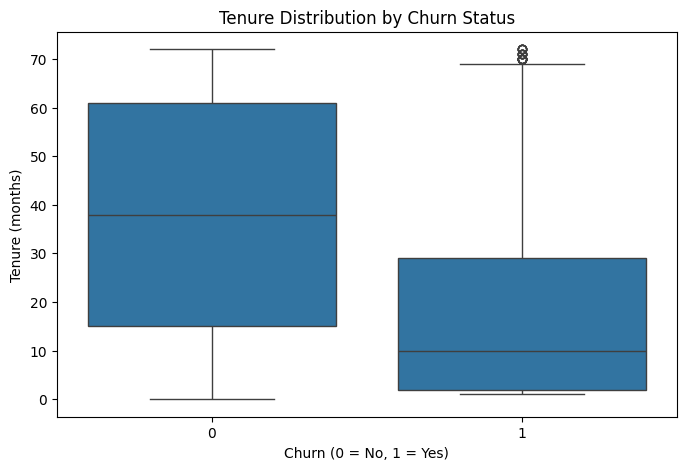

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure (months)')
plt.show()

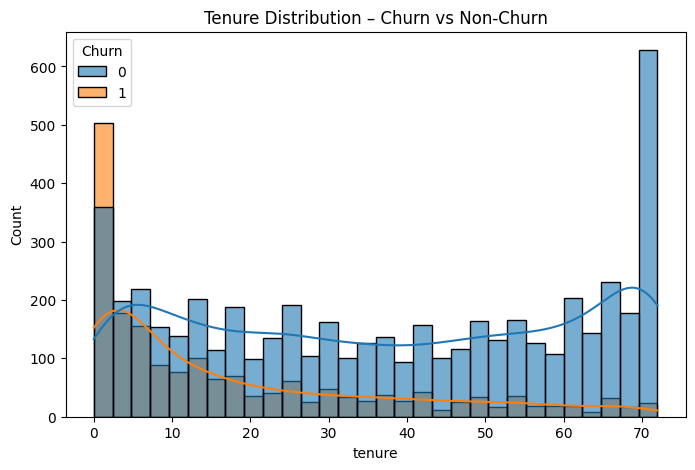

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn', kde=True, bins=30, alpha=0.6)
plt.title('Tenure Distribution – Churn vs Non‑Churn')
plt.show()

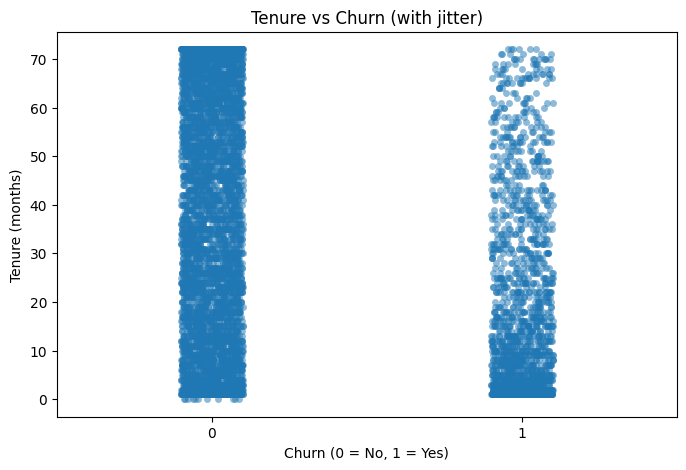

In [18]:
plt.figure(figsize=(8,5))
sns.stripplot(x='Churn', y='tenure', data=df, jitter=True, alpha=0.5)
plt.title('Tenure vs Churn (with jitter)')
plt.xlabel('Churn (0 = No, 1 = Yes)')
plt.ylabel('Tenure (months)')
plt.show()

C:\Users\InsuranceMarket.ae\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 72.7% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\InsuranceMarket.ae\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 46.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\InsuranceMarket.ae\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 75.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
C:\Users\InsuranceMarket.ae\AppData\Roaming\Python\Python312\site-packages\seaborn\categorical.py:3399: UserWarning: 49.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings

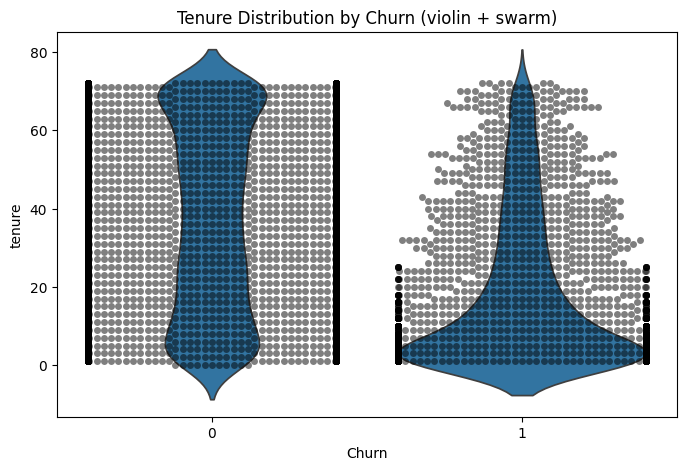

In [19]:
plt.figure(figsize=(8,5))
sns.violinplot(x='Churn', y='tenure', data=df, inner=None)
sns.swarmplot(x='Churn', y='tenure', data=df, color='k', alpha=0.5)
plt.title('Tenure Distribution by Churn (violin + swarm)')
plt.show()

# Modeling

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')

Training set size: 5634 samples
Test set size: 1409 samples


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

lr = LogisticRegression(max_iter=10000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_proba_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_lr)}")

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[928 107]
 [165 209]]
ROC AUC Score: 0.8424294091813274


In [23]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print("Random Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf)}")

Random Forest Results:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409

Confusion Matrix:
[[925 110]
 [194 180]]
ROC AUC Score: 0.8232374899894082


In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_xgb)}") 

XGBoost Results:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1035
           1       0.58      0.50      0.54       374

    accuracy                           0.77      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.77      0.77      1409

Confusion Matrix:
[[902 133]
 [188 186]]
ROC AUC Score: 0.8223836833811259


C:\Users\InsuranceMarket.ae\AppData\Roaming\Python\Python312\site-packages\xgboost\training.py:200: UserWarning: [11:40:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [25]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'ROC AUC Score': [roc_auc_score(y_test, y_proba_lr), roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_xgb)]
}) 

print(results)

                 Model  ROC AUC Score
0  Logistic Regression       0.842429
1        Random Forest       0.823237
2              XGBoost       0.822384


In [28]:
coeffs = pd.Series(lr.coef_[0], index=X.columns)
print(coeffs.sort_values(ascending=False))

InternetService_Fiber optic              1.308478
StreamingMovies_Yes                      0.426730
StreamingTV_Yes                          0.426423
MultipleLines_Yes                        0.389125
PaymentMethod_Electronic check           0.382072
PaperlessBilling                         0.373196
MultipleLines_No phone service           0.278381
SeniorCitizen                            0.147152
PhoneService                             0.131806
PaymentMethod_Mailed check               0.066003
DeviceProtection_Yes                     0.060656
Partner                                  0.022649
gender                                   0.022038
TotalCharges                             0.000255
MonthlyCharges                          -0.021178
PaymentMethod_Credit card (automatic)   -0.034512
tenure                                  -0.053148
OnlineBackup_Yes                        -0.073610
OnlineBackup_No internet service        -0.192632
OnlineSecurity_No internet service      -0.192632


In [32]:
print(df.corr()['Churn'].drop('Churn').abs().sort_values(ascending=False))

tenure                                   0.352229
InternetService_Fiber optic              0.308020
Contract_Two year                        0.302253
PaymentMethod_Electronic check           0.301919
InternetService_No                       0.227890
OnlineSecurity_No internet service       0.227890
DeviceProtection_No internet service     0.227890
TechSupport_No internet service          0.227890
StreamingMovies_No internet service      0.227890
StreamingTV_No internet service          0.227890
OnlineBackup_No internet service         0.227890
TotalCharges                             0.198324
MonthlyCharges                           0.193356
PaperlessBilling                         0.191825
Contract_One year                        0.177820
OnlineSecurity_Yes                       0.171226
TechSupport_Yes                          0.164674
Dependents                               0.164221
SeniorCitizen                            0.150889
Partner                                  0.150448


In [58]:
selected_features = [
    'tenure',
    'MonthlyCharges',
    'Contract_One year',
    'Contract_Two year',
    'InternetService_Fiber optic',
    'PaymentMethod_Electronic check',
    'PaperlessBilling',
    'OnlineSecurity_Yes',
    'TechSupport_Yes',
    'Dependents',
    'SeniorCitizen',
]

X_sel = X[selected_features]

# Train/test split
X_train_sel, X_test_sel, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic regression
lr_sel = LogisticRegression(max_iter=10000, random_state=42)
lr_sel.fit(X_train_sel, y_train)

# Predictions and probabilities
y_pred_sel = lr_sel.predict(X_test_sel)
y_proba_sel = lr_sel.predict_proba(X_test_sel)[:, 1]

print("=== Logistic Regression (Selected Features) ===")
print(classification_report(y_test, y_pred_sel))
print(f"AUC: {roc_auc_score(y_test, y_proba_sel):.3f}")


=== Logistic Regression (Selected Features) ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.63      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

AUC: 0.835


In [59]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Assuming y_test and y_proba_sel exist from your logistic regression on selected features
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_sel)
target_recall = 0.70
idx = np.argmax(recalls >= target_recall)
new_thresh = thresholds[idx]
print(f"Threshold for recall >= {target_recall}: {new_thresh:.3f}")

y_pred_tuned = (y_proba_sel >= new_thresh).astype(int)
print("\nClassification report with tuned threshold:")
print(classification_report(y_test, y_pred_tuned))

Threshold for recall >= 0.7: 0.004

Classification report with tuned threshold:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1035
           1       0.27      1.00      0.42       374

    accuracy                           0.27      1409
   macro avg       0.13      0.50      0.21      1409
weighted avg       0.07      0.27      0.11      1409



C:\Users\InsuranceMarket.ae\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\InsuranceMarket.ae\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\InsuranceMarket.ae\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [60]:
from sklearn.metrics import precision_recall_curve, f1_score

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_sel)

# Calculate F1 for each threshold (ignore the last value, which corresponds to no positive predictions)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)  # avoid division by zero
best_idx = np.argmax(f1_scores[:-1])  # thresholds exclude last point
best_thresh = thresholds[best_idx]
print(f"Best threshold by F1: {best_thresh:.3f}")
print(f"F1 at best threshold: {f1_scores[best_idx]:.3f}")

# Apply best threshold
y_pred_best = (y_proba_sel >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_best))

Best threshold by F1: 0.290
F1 at best threshold: 0.619
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [61]:
lr_balanced = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_balanced.fit(X_train_sel, y_train)
y_proba_bal = lr_balanced.predict_proba(X_test_sel)[:,1]
y_pred_bal = lr_balanced.predict(X_test_sel)
print(classification_report(y_test, y_pred_bal))
print("AUC:", roc_auc_score(y_test, y_proba_bal))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.80      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.73      0.75      1409

AUC: 0.8339494691157093


In [62]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_sel, y_train)

rf_res = RandomForestClassifier(n_estimators=100, random_state=42)
rf_res.fit(X_train_res, y_train_res)
y_pred_res = rf_res.predict(X_test_sel)
print(classification_report(y_test, y_pred_res))

              precision    recall  f1-score   support

           0       0.85      0.81      0.83      1035
           1       0.53      0.61      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.76      1409



In [63]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_sel)

# Target precision (e.g., 0.65)
target_precision = 0.65
# Find the highest recall with precision >= target_precision
mask = precisions >= target_precision
if any(mask):
    best_recall_idx = np.argmax(recalls[:-1][mask[:-1]])  # ignore last point
    best_thresh = thresholds[best_recall_idx]
    print(f"Threshold for precision >= {target_precision}: {best_thresh:.3f}")
    print(f"Recall at that threshold: {recalls[best_recall_idx]:.3f}")
    print(f"Precision: {precisions[best_recall_idx]:.3f}")
else:
    print("Can't achieve that precision with this model.")

Threshold for precision >= 0.65: 0.004
Recall at that threshold: 1.000
Precision: 0.265


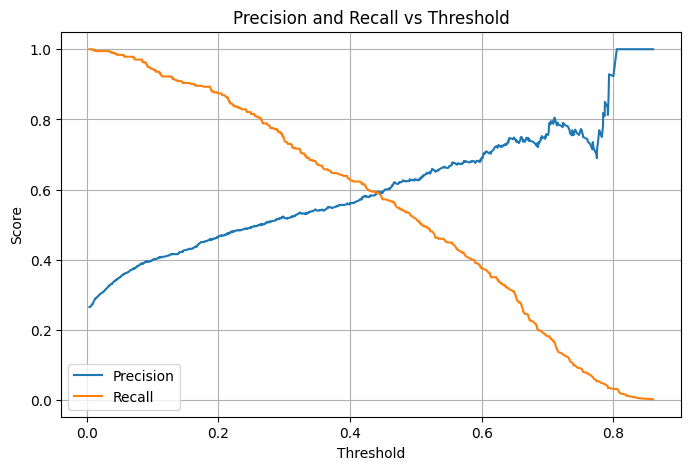

In [64]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_sel)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Threshold')
plt.legend()
plt.grid()
plt.show()

In [65]:
target_precision = 0.60
for thresh, prec, rec in zip(thresholds, precisions[:-1], recalls[:-1]):
    if prec >= target_precision:
        print(f"Threshold: {thresh:.3f} -> Precision: {prec:.3f}, Recall: {rec:.3f}")
        break

Threshold: 0.454 -> Precision: 0.601, Recall: 0.572


In [66]:
import joblib

# Save the model
joblib.dump(lr_sel, 'churn_model.pkl')

# Save the threshold
with open('churn_threshold.txt', 'w') as f:
    f.write("0.29")

# Also save the list of selected features (for inference)
import json
with open('selected_features.json', 'w') as f:
    json.dump(selected_features, f)

print("Model, threshold, and features saved.")

Model, threshold, and features saved.
